In [23]:
import sys
import json

general = {'use_road_network': True}
footpaths = {'max_length': '1000', 'speed': '4.8', 'n_ntlegs': '2'}

params = {'footpaths': footpaths, 'general': general}

default = {'training_folder': '../../', 'scenario': 'noumea_with_timetable', 'params': params, 'period': 'am'}
manual, argv = (True, default) if 'ipykernel' in sys.argv[0] else (False, dict(default, **json.loads(sys.argv[1])))
print(argv)

{'training_folder': '../../', 'scenario': 'noumea_with_timetable', 'params': {'footpaths': {'max_length': '1000', 'speed': '4.8', 'n_ntlegs': '2'}, 'general': {'use_road_network': True}}, 'period': 'am'}


In [24]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from datetime import datetime

sys.path.insert(0, r'../../../quetzal')  # Add path to quetzal
from shapely.geometry import Point, LineString
from shapely import union_all
from quetzal.model import stepmodel, connectionscanmodel
from quetzal.io.quenedi import read_parameters, restrict_df_to_variant
from syspy.spatial.utils import get_epsg
from syspy.spatial.spatial import DBSCAN_sclustering, voronoi_diagram_dataframes, zone_clusters, get_links_hull


on_lambda = bool(os.environ.get('AWS_EXECUTION_ENV'))
num_cores = os.cpu_count()
print('num cores:', num_cores, 'on_lambda:', on_lambda)

num cores: 16 on_lambda: False


# Folders stucture and params

everything is on S3 (nothing on ECR) so no direct input folder. just scenarios/{scen}/inputs/

In [25]:
#period = argv.get('period', '')
### TODO add params: start_time, end_time, transfer_penalty

In [26]:
scenario = argv['scenario']
training_folder = argv['training_folder']

# if local. add the path to the scenario scenarios/<scenario>/
local_scen_path = '' if on_lambda else os.path.join('scenarios/', scenario)

input_folder = os.path.join(training_folder, 'inputs/')
scenario_folder = os.path.join(training_folder, local_scen_path, 'inputs/')
model_folder = os.path.join(training_folder, local_scen_path, 'model/')
output_folder = os.path.join(training_folder, local_scen_path, 'outputs/')

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print('input folder: ', scenario_folder)
print('output folder: ', output_folder)

input folder:  ../../scenarios/noumea_with_timetable\inputs/
output folder:  ../../scenarios/noumea_with_timetable\outputs/


In [27]:
params = read_parameters(argv['params'])#, period=period)

rnodes_file = os.path.join(scenario_folder, 'road/road_nodes.geojson')
rnodes_file_provided = os.path.isfile(rnodes_file)

zonage_file = os.path.join(scenario_folder, 'zonage.geojson')
zonage_file_provided = os.path.isfile(zonage_file)

od_file = os.path.join(scenario_folder, 'od/od.geojson')
od_file_provided = os.path.isfile(od_file)

In [28]:
max_length = float(params['footpaths']['max_length'])
speed = float(params['footpaths']['speed'])
n_ntlegs = int(params['footpaths']['n_ntlegs'])
cutoff = 3 * 60 * 60  # 3 hours
use_road_network = params['general'].get('use_road_network', False)

In [29]:
walk_on_road = (rnodes_file_provided & use_road_network)

In [30]:
print('rnodes_file_provided?', rnodes_file_provided)
print('zonage_file_provided?', zonage_file_provided)
print('od_file_provided?', od_file_provided)

print('walk_on_road?', walk_on_road)

rnodes_file_provided? True
zonage_file_provided? True
od_file_provided? True
walk_on_road? True


# inputs

In [31]:
# un connectionscanmodel peut-il overwrite un stepmode dans le dossier modèles ?
model = connectionscanmodel.read_zippedpickles(model_folder + 'cleaned')

zones: 100%|██████████| 15/15 [00:00<00:00, 179.36it/s]


In [32]:
if not model.timetable_used:
    end_of_notebook

In [33]:
crs = model.crs

In [66]:
transfer_penalty = 0

In [34]:
### TODO: problème dans le réseau routier, tous les liens sont à oneway=1

In [35]:
### TODO: 

# Refaire tourner le main et le pathfinder pour vérifier que tout fonctionne toujours correctement.

# intergrity_tests ### RATE
# tout horaire ou tout freq ### X
# borner seulement / départ ### X
# pathfinder à l'od ### mettre le deuxième nb après (fonctionnement so différent)
### Il y a des incohérences entre le temps associé à un link et la différence de temps entre le moment d'arrivée et le départ -> pourquoi ?
### Prise en compte du stop interval ? oui, on dit qu'il est pris en compte dans la timetable: la timetable reflète l'heure de départ de la station et non d'arrivée en gare (? pas sûr)
# coûts d'exploitation ### X
# output user vs auto variable
# est-ce vraiment utile de garder le projet dans un crs local ? ### X oui pour avoir des distances/aires en mètres facilement

# isochrones passer par clusters d'arrêts (mega merge en polars en deux fois) 1
# faire les tests avec beaucoup de zones avec le projet bateau.

# tester la rétrocompatibilité (avec clermont 4, en local et en ligne)

# mettre en ligne et faire des tests
# guide utilisateur

# Preparation

In [36]:
def time_seconds(time_str):
    time_obj = datetime.strptime(time_str, '%H:%M:%S')
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second

def seconds_time(total_seconds):
    total_seconds = int(total_seconds) % (24 * 3600)
    h = total_seconds // 3600
    m = (total_seconds % 3600) // 60
    #s = total_seconds % 60
    return f"{h:02d}:{m:02d}"#:{s:02d}"

In [37]:
start_time = '7:00:00'
start_time = time_seconds(start_time)

end_time = '10:00:00'
end_time = time_seconds(end_time)

In [38]:
# clustering and rename nodes
model.preparation_clusterize_nodes(distance_threshold=100, fast=True, prefix='cnode_')  # modèle déjà configuré en crs métrique.
model.nodes.index.name = 'index'

can not add prefixes on table:  footpaths


In [39]:
links_with_times = model.links[['trip_id', 'a', 'b', 'departures', 'arrivals']].explode(['departures', 'arrivals'])
links_with_times = links_with_times.rename(columns={'departures':'departure_time', 'arrivals': 'arrival_time'})
links_with_times['journey'] = links_with_times.groupby(['trip_id', 'a', 'b']).cumcount() + 1

In [40]:
model.links = model.links.drop(columns=['departures', 'arrivals'])
model.links = model.links.merge(links_with_times[['departure_time', 'arrival_time', 'journey']], left_index=True, right_index=True, how='right')
model.links['departure_time'] = model.links['departure_time'].apply(time_seconds)
model.links['arrival_time'] = model.links['arrival_time'].apply(time_seconds)

In [41]:
model.links['trip_id'] = model.links['trip_id'] + '_' + model.links['journey'].astype(str)
model.links.drop(columns='journey', inplace=True)

In [42]:
model.links.sort_values(['trip_id', 'departure_time'], inplace=True)
model.links = model.links.reset_index(drop=True)
model.links.index = 'link_' + model.links.index.astype(str)
model.links.index.name = 'index'

In [43]:
model.links['time_diff'] = model.links['arrival_time'] - model.links['departure_time']
model.links['delta'] = model.links['time_diff'] - model.links['time']
model.links.sort_values('delta')

,geometry,route_id,trip_id,route_short_name,anchors,b,time,shape_dist_traveled,road_link_list,length,...,b_name,fleet,a_terminus,b_terminus,disaggregated_a,disaggregated_b,departure_time,arrival_time,time_diff,delta
index,,,,,,,,,,,,,,,,,,,,,
link_6232,"LINESTRING (649804.76 7539600.88, 649821.378 7...",NEOBUS_L1,NEOBUS_L1_1_8,L1,None,cnode_163,60.0,923,None,915,...,ROND POINT BONAPARTE,5,False,False,node_257,node_372,32521,32581,60,0.0
link_6233,"LINESTRING (650588.122 7539693.874, 650670.519...",NEOBUS_L1,NEOBUS_L1_1_8,L1,None,cnode_114,60.0,478,None,479,...,ECOLE BURCK,5,False,False,node_372,node_246,32581,32641,60,0.0
link_6234,"LINESTRING (650802.175 7540115.995, 650928.605...",NEOBUS_L1,NEOBUS_L1_1_8,L1,None,cnode_115,120.0,620,None,620,...,PARC RIVIERE SALEE,5,False,False,node_246,node_248,32641,32761,120,0.0
link_6235,"LINESTRING (651149.195 7540599.608, 651232.477...",NEOBUS_L1,NEOBUS_L1_1_8,L1,None,cnode_6,120.0,709,None,708,...,ECOLE TROUILLOT,5,False,False,node_248,node_249,32761,32881,120,0.0
link_6236,"LINESTRING (651648.247 7541046.859, 651771.991...",NEOBUS_L1,NEOBUS_L1_1_8,L1,None,cnode_52,120.0,938,None,940,...,PROMENADE DE KOUTIO,5,False,False,node_249,node_101,32881,33001,120,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
link_6258,"LINESTRING (650516.779 7543284.495, 650477.259...",NEOBUS_L1,NEOBUS_L1_1_9,L1,None,cnode_25,122.0,412,None,411,...,ANTOINE BECQUEREL,5,False,False,node_181,node_374,39060,39182,122,0.0
link_6259,"LINESTRING (650200.891 7543522.161, 650127.076...",NEOBUS_L1,NEOBUS_L1_1_9,L1,None,cnode_146,120.0,683,None,680,...,ERUDITS,5,False,False,node_374,node_688,39182,39302,120,0.0
link_6260,"LINESTRING (649700.811 7543680.757, 649808.862...",NEOBUS_L1,NEOBUS_L1_1_9,L1,None,cnode_112,60.0,526,None,527,...,FARE DU MEDIPOLE,5,False,False,node_688,node_695,39302,39362,60,0.0


In [44]:
# cette ligne est inutile
model.links = model.links.loc[(model.links['departure_time'] > start_time) & (model.links['departure_time'] < end_time)]

# Isochrone

Use voronoi method to clusterize nodes to perform isochrone algorithm
If no zonage is provided, isochrone uses the voronoi zonage for the display
If a zonage was provided, isochrone will be projected onto this zonage (polars mega merge en deux fois arrivee puis depart) (à vol d'oiseau pour commencer, puis on le fera avec le réseau routier)

In [45]:
if not zonage_file_provided:
    # get envelope fo clip the voronoi
    clip_geometry = get_links_hull(model.links, tolerance=1e-2)

    # 1) Clusterize nodes that are really close
    clustered_nodes = model.nodes.copy()
    label = DBSCAN_sclustering(clustered_nodes, distance_threshold=2e-3)
    label = 'node_cluster_' + label.astype(str)
    clustered_nodes['cluster'] = label
    nodes_cluster_series = clustered_nodes['cluster']

    clustered_nodes = clustered_nodes.drop_duplicates('cluster')
    clustered_nodes = clustered_nodes.reset_index().set_index('cluster')

    # 2) create a voronoi with nodes clusters
    voronoi, _ = voronoi_diagram_dataframes(clustered_nodes['geometry'])
    voronoi.crs = crs

    voronoi = voronoi.clip(clip_geometry)

    # 3) Clusterize the voronoi into 500 zones
    clusters, cluster_series = zone_clusters(voronoi, n_clusters=500, geo_join_method=union_all)
    clusters = gpd.GeoDataFrame(clusters)

    cluster_series = 'zones_' + cluster_series.astype(str)
    clusters.index = 'zones_' + clusters.index.astype(str)
    clusters.index.name = 'index'

    zone_cluster_dict = cluster_series.reset_index().groupby('cluster')['index'].agg(list).to_dict()
    clusters['node_cluster_list'] = clusters.index.map(zone_cluster_dict.get)
    clusters['node_cluster_id'] = clusters['node_cluster_list'].apply(lambda x: x[0])

    node_cluster_dict = nodes_cluster_series.reset_index().groupby('cluster')['index'].agg(list).to_dict()
    clusters['node_list'] = clusters['node_cluster_list'].apply(lambda x: [*map(node_cluster_dict.get, x)])
    clusters['node_list'] = clusters['node_list'].apply(lambda ls: [item for sublist in ls for item in sublist])  # flatten
    clusters['node_id'] = clusters['node_list'].apply(lambda x: x[0])

    zones = model.nodes.loc[clusters['node_id'].values].copy()
    zones = zones.reset_index().rename(columns={'index': 'node_id'})
    zone_node_dict = clusters.reset_index().set_index('node_id')['index'].to_dict()

    zones.index = zones['node_id'].apply(zone_node_dict.get)
    zones.index.name = 'index'

    model_iso = model.copy()
    model_iso.zones = zones.copy()

In [46]:
if zonage_file_provided:
    model_iso = model.copy()
    clusters = model_iso.zones.copy() ### Clusterizer les zones si il y en a trop ? comment ? pour garder un zonage assez précis.
    model_iso.zones['geometry'] = model_iso.zones['geometry'].apply(lambda x: x.centroid)
    
clusters.to_crs(epsg='4326')[['geometry']].to_file(os.path.join(output_folder, 'isochrone_1214.geojson'), driver='GeoJSON')

In [47]:
model_iso.preparation_footpaths(speed=speed, max_length=max_length)

model_iso.footpaths = model_iso.footpaths.drop(columns='voronoi')
model_iso.footpaths['speed'] = model_iso.footpaths['length'] / model_iso.footpaths['time'] * 3.6
model_iso.footpaths['duration'] = model_iso.footpaths['time']

In [48]:
model_iso.preparation_ntlegs(
    short_leg_speed=speed,
    long_leg_speed=speed,  # tout le monde marche
    zone_to_transit=True,
    zone_to_road=walk_on_road,
    road_to_transit=walk_on_road,
    n_ntlegs=n_ntlegs,
)

model_iso.zone_to_transit.index = 'ztt_' + model_iso.zone_to_transit.index.astype(str)
model_iso.zone_to_road.index = 'ztr_' + model_iso.zone_to_road.index.astype(str)
model_iso.road_to_transit.index = 'rtt_' + model_iso.road_to_transit.index.astype(str)

connect zone to every nodes in its cluster

In [49]:
if not zonage_file_provided:
    zone_to_transit = clusters[['node_list']].explode('node_list').reset_index()

    zone_to_transit['rank'] = 0
    zone_to_transit['distance'] = 0
    zone_to_transit['geometry'] = LineString([[0, 0], [0, 0]])
    zone_to_transit['direction'] = 'access'
    zone_to_transit['speed_factor'] = 0
    zone_to_transit['short_leg_speed'] = speed
    zone_to_transit['long_leg_speed'] = speed
    zone_to_transit['speed'] = speed
    zone_to_transit['time'] = 0
    zone_to_transit['walk_time'] = 0

    access = zone_to_transit.rename(columns={'index': 'a', 'node_list': 'b'})
    eggress = zone_to_transit.rename(columns={'index': 'b', 'node_list': 'a'})
    eggress['direction'] = 'eggress'

    model_iso.zone_to_transit = pd.concat([model_iso.zone_to_transit, access, eggress], ignore_index=True)

In [50]:
#self.step_pt_pathfinder(
#    broken_routes=False,
#    broken_modes=False,
#    keep_pathfinder=True,
#    cutoff=cutoff,
#    mode_column='route_type',
#    route_column='route_id',
#    speedup=True,
#    walk_on_road=walk_on_road,
#    path_analysis=False,
#)

### Fonctionnement à la fréquence: faut-il recréer un fonctionnement à l'horaire 
# à partir des tableaux de fonctionnement à la fréquence ? Plutôt que de se battre pour que les deux fonctionnements coexistent ?

model_iso.step_pt_pathfinder(
    min_transfer_time=0,
    time_interval=[start_time, end_time],
    cutoff=np.inf,
    build_connections=True,
    targets=None,
    od_set=None,
    workers=1,
    reindex=True,
    step=None,
)

model_iso.analysis_paths()

  6%|▌         | 373/6450 [01:16<20:47,  4.87it/s]


KeyboardInterrupt: 

In [ ]:
transfer_penalty = 0

model_iso.pt_los['time'] = model_iso.pt_los['arrival_time'] - model_iso.pt_los['departure_time']
model_iso.pt_los['gtime'] = model_iso.pt_los['time'] + model_iso.pt_los['ntransfers']*transfer_penalty
model_iso.pt_los['time (mins)'] = model_iso.pt_los['gtime'] / 60

In [ ]:
def agg_func(x):
    return dict(x.values)

json_data = {}
grouped = model_iso.pt_los.groupby(['origin', 'destination'])['time (mins)'].min().reset_index() ### Le max à changer si on travaille à la fréquence ?
grouped['time (mins)'] = list(zip(grouped['destination'], grouped['time (mins)']))
data = grouped.groupby('origin').agg({'time (mins)': agg_func}).to_dict()
json_data.update(data)

In [ ]:
with open(os.path.join(output_folder, 'isochrone_1214.json'), 'w') as json_file:
    json.dump(json_data, json_file)

# OD pathfinder

In [67]:
od_file = os.path.join(scenario_folder, 'od', 'od.geojson')
od_file_provided = os.path.isfile(od_file)
if od_file_provided:
    od_test = gpd.read_file(od_file)
    if 'index' not in od_test.columns:
        od_test.reset_index(names='index', inplace=True)
    od_test['index'] = od_test['index'].astype(str).apply(lambda x: 'od_' + x if 'od_' not in x else x)
    od_test.set_index('index', inplace=True)
else:
    print('end of pathfinder')
    end_of_notebook

end_of_notebook here if OD_file not provided!!

In [68]:
od_test['geometry_o'] = od_test['geometry'].apply(lambda g: Point(g.coords[:][0]))
od_test['geometry_d'] = od_test['geometry'].apply(lambda g: Point(g.coords[:][1]))

od_test['origin'] = od_test.index + '_o'
od_test['destination'] = od_test.index + '_d'

zones = od_test.copy()
zones_d = od_test.copy()
zones['geometry'] = zones['geometry_o']
zones_d['geometry'] = zones_d['geometry_d']
zones['index'] = zones['origin']
zones_d['index'] = zones_d['destination']
zones = pd.concat([zones[['index', 'geometry']], zones_d[['index', 'geometry']]])
zones = zones.to_crs(crs=crs).set_index('index')

od_set = set(zip(od_test['origin'], od_test['destination']))

# Walkmodel

In [69]:
model.zones = zones

In [70]:
model.preparation_footpaths(speed=speed, max_length=500)

model.footpaths = model.footpaths.drop(columns='voronoi')
model.footpaths['speed'] = model.footpaths['length'] / model.footpaths['time'] * 3.6
model.footpaths['duration'] = model.footpaths['time']

In [71]:
model.preparation_ntlegs(
    short_leg_speed=speed,
    long_leg_speed=speed,  # tout le monde marche
    zone_to_transit=True,
    zone_to_road=walk_on_road,
    road_to_transit=walk_on_road,
    n_ntlegs=5,
)

model.zone_to_transit.index = 'ztt_' + model.zone_to_transit.index.astype(str)
model.zone_to_road.index = 'ztr_' + model.zone_to_road.index.astype(str)
model.road_to_transit.index = 'rtt_' + model.road_to_transit.index.astype(str)

# pathfinder

In [ ]:
min_transfer_time = 30

if 'volume' in od_test.columns:
    od_test = od_test.loc[od_test['volume'] > 0]
    print('computing shortest paths only for ODs with ')
od_set = {(i+'_o', i+'_d') for i in od_test.index}

model.step_pt_pathfinder(
    min_transfer_time=min_transfer_time,
    time_interval=[start_time, end_time],
    cutoff=np.inf,
    build_connections=True,
    targets=None,
    od_set=od_set,
    workers=1,
    reindex=False,
    step=None,
)

computing shortest paths only for ODs with 


100%|██████████| 2/2 [00:00<00:00,  2.07it/s]


In [73]:
model.footpaths.head(1)

,a,b,geometry,length,time,speed,duration,model_index
footpath_0,cnode_124,cnode_202,LINESTRING (649232.7454661379 7532400.43789245...,242.547839,181.910879,4.8,181.910879,footpath_0


In [74]:
model.footpaths = pd.merge(
    model.time_expended_footpaths, 
    model.footpaths[['geometry', 'length', 'time', 'speed', 'duration']], 
    left_on = 'model_index', 
    right_index = True
)

model.footpaths['model_index'] = model.footpaths['csa_index'].copy()
model.footpaths.set_index('csa_index', inplace=True)

In [75]:
model.zone_to_transit = pd.merge(
    model.time_expended_zone_to_transit, 
    model.zone_to_transit[['geometry', 'speed_factor', 'short_leg_speed', 'long_leg_speed', 'speed', 'time', 'walk_time']], 
    left_on = 'model_index', 
    right_index = True
)

model.zone_to_transit['model_index'] = model.zone_to_transit['csa_index'].copy()
model.zone_to_transit.set_index('csa_index', inplace=True)

In [76]:
model.pseudo_connections['model_index'] = model.pseudo_connections['csa_index'].copy()

In [77]:
model.analysis_paths()

100%|██████████| 4/4 [00:00<?, ?it/s]


In [78]:
model.pseudo_connections

,a,b,departure_time,arrival_time,min_transfer_time,trip_id,link_sequence,link_index,model_index,actual_departure_time,csa_index,direction
296674,cnode_90,od_4193_o,36051.000000,36484.353448,NaN,ztt_trip_642878,NaN,NaN,ztt_ztt_125225_642878,36051.000000,ztt_ztt_125225_642878,egress
296709,cnode_90,od_4198_o,36051.000000,36484.353448,NaN,ztt_trip_642913,NaN,NaN,ztt_ztt_125230_642913,36051.000000,ztt_ztt_125230_642913,egress
323160,cnode_90,od_2511_d,36051.000000,36484.353448,NaN,ztt_trip_669364,NaN,NaN,ztt_ztt_130267_669364,36051.000000,ztt_ztt_130267_669364,egress
341422,cnode_90,od_6283_d,36051.000000,36484.353448,NaN,ztt_trip_687626,NaN,NaN,ztt_ztt_134039_687626,36051.000000,ztt_ztt_134039_687626,egress
296604,cnode_90,od_4183_o,36051.000000,36484.353448,NaN,ztt_trip_642808,NaN,NaN,ztt_ztt_125215_642808,36051.000000,ztt_ztt_125215_642808,egress
...,...,...,...,...,...,...,...,...,...,...,...,...
140209,od_5998_d,cnode_84,21585.275458,25318.000000,NaN,ztt_trip_140209,NaN,NaN,ztt_ztt_26170_140209,21585.275458,ztt_ztt_26170_140209,access
73448,od_995_o,cnode_84,21585.275458,25318.000000,NaN,ztt_trip_73448,NaN,NaN,ztt_ztt_14443_73448,21585.275458,ztt_ztt_14443_73448,access
73483,od_1002_o,cnode_84,21585.275458,25318.000000,NaN,ztt_trip_73483,NaN,NaN,ztt_ztt_14450_73483,21585.275458,ztt_ztt_14450_73483,access
73453,od_996_o,cnode_84,21585.275458,25318.000000,NaN,ztt_trip_73453,NaN,NaN,ztt_ztt_14444_73453,21585.275458,ztt_ztt_14444_73453,access


In [79]:
model.pt_los['link_path'] = model.pt_los['path'].apply(lambda x: [link for link in x if 'link_' in link])
model.pt_los['footpaths'] = model.pt_los['path'].apply(lambda x: [link for link in x if 'footpath_' in link])
model.pt_los['ntlegs'] = model.pt_los['path'].apply(lambda x: [link for link in x if 'ztt_' in link])

model.pt_los['itinerary_id'] = model.pt_los.apply(lambda x: '_'.join([x['origin'].replace('_o', ''), str(int(x['departure_time'])), str(int(x['arrival_time']))]), 1)
# En ajoutant le réseau routier il faudra ajouter les autres catégories possibles

In [80]:
### il faut réparer le truc pour supprimer les boucles et les remplacer par du temps d'attente (pour ça regarder l'entièreté du chemin et regarder les nodes arrivée qui vont bien)
### il faut aussi voir si qqch a changé dans le connection path et si c'est plus logique désormais (pourquoi y a t il des connexions inutiles, peut-être qu'en mettant une pénalité pour la marche on pourra contrer cet effet ?)

In [81]:
model.pt_los['time'] = model.pt_los['arrival_time'] - model.pt_los['departure_time']
model.pt_los['gtime'] = model.pt_los['time'] + model.pt_los['ntransfers']*transfer_penalty
model.pt_los['time (mins)'] = model.pt_los['gtime'] / 60

# create path

In [82]:
od_links = od_test[['origin', 'destination']].reset_index(names='od_index').merge(model.pt_los[['itinerary_id', 'origin', 'destination', 'departure_time', 'arrival_time', 'gtime', 'link_path']], on=['origin', 'destination'])
od_links = od_links.drop(columns=['origin', 'destination'])
od_links = od_links.explode('link_path')
od_links.rename(columns={'departure_time': 'itinerary_departure_time', 'arrival_time': 'itinerary_arrival_time'}, inplace=True)

# may add route_width if quenedi can handle it one day.
od_links = od_links.merge(model.links[['a', 'b', 'route_color', 'departure_time', 'arrival_time', 'geometry', 'time', 'speed', 'trip_id']], left_on='link_path', right_index=True)
od_links['type'] = 'link'
# od_links = od_links.drop(columns='link_path')

In [83]:
od_ntlegs = od_test[['origin', 'destination']].reset_index(names='od_index').merge(model.pt_los[['itinerary_id', 'origin', 'destination', 'departure_time', 'arrival_time', 'gtime', 'ntlegs']], on=['origin', 'destination'])
od_ntlegs = od_ntlegs.drop(columns=['origin', 'destination'])
od_ntlegs = od_ntlegs.explode('ntlegs')
od_ntlegs.rename(columns={'departure_time': 'itinerary_departure_time', 'arrival_time': 'itinerary_arrival_time'}, inplace=True)

od_ntlegs = od_ntlegs.merge(model.zone_to_transit[['a', 'b', 'geometry', 'departure_time', 'arrival_time', 'time', 'speed', 'trip_id']], left_on='ntlegs', right_index=True)
od_ntlegs = od_ntlegs.drop(columns='ntlegs')
od_ntlegs['route_color']='4B4B4B'
od_ntlegs['type'] = 'ntleg'

In [84]:
od_footpaths = od_test[['origin', 'destination']].reset_index(names='od_index').merge(model.pt_los[['itinerary_id', 'origin', 'destination', 'departure_time', 'arrival_time', 'gtime', 'footpaths']], on=['origin', 'destination'])
od_footpaths = od_footpaths.drop(columns=['origin', 'destination'])
od_footpaths = od_footpaths.explode('footpaths')
od_footpaths.rename(columns={'departure_time': 'itinerary_departure_time', 'arrival_time': 'itinerary_arrival_time'}, inplace=True)

od_footpaths = od_footpaths.merge(model.footpaths[['a', 'b' ,'geometry', 'departure_time', 'arrival_time', 'time', 'speed', 'trip_id']], left_on='footpaths', right_index=True)
od_footpaths = od_footpaths.drop(columns='footpaths')
od_footpaths['type'] = 'footpath'

In [85]:
od_route = pd.concat([od_links, od_footpaths, od_ntlegs])

In [86]:
od_route['route_color'] = od_route['route_color'].fillna('838383').replace('null', '838383')
od_route['route_color'] = od_route['route_color'].apply(lambda c: f'#{c.strip()}')

In [87]:
od_route = gpd.GeoDataFrame(od_route, crs=crs)
od_route.to_file(os.path.join(output_folder, 'od_route.geojson'), driver='GeoJSON')

In [88]:
od_route['mode'] = od_route['link_path'].map(model.links['route_type'].to_dict()).fillna('walk')

# export PT lost metrics

In [89]:
modes = list(od_route['mode'].unique())

In [90]:
model.analysis_pt_route_type(modes)

In [91]:
for mode in modes:
    temp = od_route.loc[od_route['mode'] == mode].groupby(['itinerary_id'])['time'].sum().to_dict()
    model.pt_los['{}_time'.format(mode)] = model.pt_los['itinerary_id'].map(temp).fillna(0)

access_time_dict = od_route.loc[od_route['type'] == 'ntleg'].groupby(['itinerary_id'])['time'].sum().to_dict()
model.pt_los['access_time'] = model.pt_los['itinerary_id'].map(access_time_dict).fillna(0)

footpath_time_dict = od_route.loc[od_route['type'] == 'footpath'].groupby(['itinerary_id'])['time'].sum().to_dict()
model.pt_los['footpath_time'] = model.pt_los['itinerary_id'].map(footpath_time_dict).fillna(0)

model.pt_los['waiting_time'] = model.pt_los['time'] - model.pt_los[['{}_time'.format(mode) for mode in modes if mode != 'walk'] + ['access_time', 'footpath_time']].sum(axis=1)

In [92]:
### CHOIX DU CHEMIN LE PLUS INTERESSANT ET SAUVEGARDE DU PT_LOS.csv

pt_los = model.pt_los
relevant_cols = ['ntransfers', 'itinerary_id'] + [col for col in model.pt_los.columns if 'time' in col]
time_cols = [col for col in model.pt_los.columns if 'time' in col if col not in ['departure_time', 'arrival_time', 'time', 'gtime', 'time (mins)', 'walk_time']]
#model.pt_los.columns
#['departure_time', 'arrival_time', 'ntransfers', 'itinerary_id'] + [col for col in model.pt_los.columns if 'time' in col]
# pt_los.to_csv(os.path.join(output_folder, 'od_los.csv'))

# Bar plot

In [93]:
import matplotlib.pyplot as plt

systra_colors = [
    '#74a9cf',
    '#0570b0',
    '#bdc9e1',
    '#b2df8a',
    '#33a02c',
    '#fb9a99',
    '#e31a1c',
    '#fdbf6f',
    '#ff7f00',
    '#cab2d6',
    '#6a3d9a',
]


In [94]:
to_plot = pt_los.copy()
to_plot = to_plot.set_index('itinerary_id')
to_plot[time_cols] = to_plot[time_cols] / 60

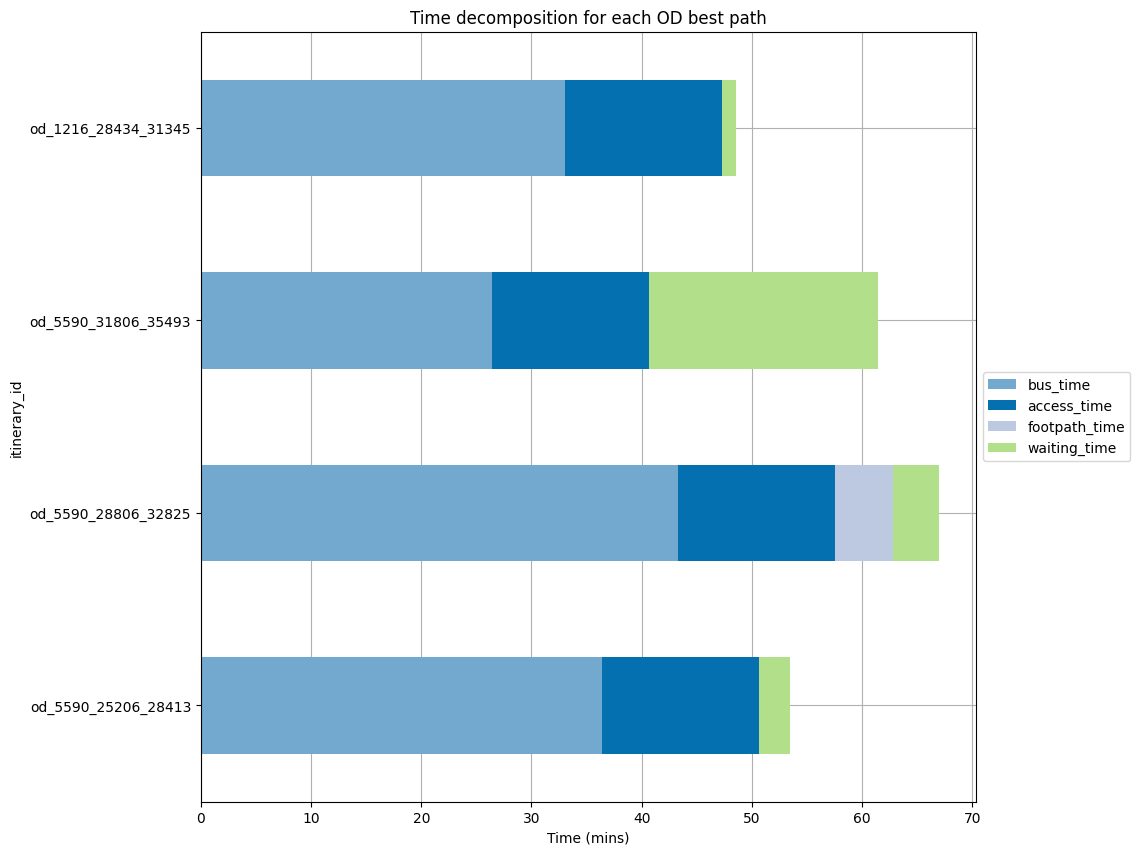

In [95]:
ax = to_plot[time_cols].plot(kind='barh', stacked=True, figsize=(10, 10), color=systra_colors)
plt.legend(loc='upper right', ncol=1)
plt.gca().invert_yaxis()
plt.xlabel('Time (mins)')
plt.grid(True, 'major', linestyle='-', axis='both')
ax.set_axisbelow(True)
plt.legend(time_cols, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.title('Time decomposition for each OD best path')
plt.savefig(os.path.join(output_folder, 'od_time_decomposition.png'))

# Png of paths

In [96]:
from syspy.spatial.spatial import plot_lineStrings
import numpy as np

In [97]:
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO


def lonlat_to_meters(lon, lat):
    """Convert lon/lat to meters in Web Mercator."""
    origin_shift = 2 * np.pi * 6378137 / 2.0
    mx = lon * origin_shift / 180.0
    my = np.log(np.tan((90 + lat) * np.pi / 360.0)) * 6378137
    return mx, my


def calculate_zoom_to_fit_bbox(minx, miny, maxx, maxy, target_width_px, target_height_px, tile_size=256):
    """
    Calculate the appropriate zoom level to fit a bounding box into a fixed pixel size.
    Returns an approximate integer zoom.
    """
    # Convert bbox corners to Web Mercator meters
    mx1, my1 = lonlat_to_meters(minx, miny)
    mx2, my2 = lonlat_to_meters(maxx, maxy)

    # Get span in meters
    width_m = abs(mx2 - mx1)
    height_m = abs(my2 - my1)

    # Calculate resolution required (meters per pixel)
    res_x = width_m / target_width_px
    res_y = height_m / target_height_px
    target_res = max(res_x, res_y)

    # Initial resolution at zoom 0
    initial_res = 2 * np.pi * 6378137 / tile_size

    # Compute zoom level from resolution
    zoom = np.log2(initial_res / target_res)

    return int(round(zoom))


def deg2num(lat_deg, lon_deg, zoom):
    lat_rad = np.radians(lat_deg)
    n = 2.0**zoom
    xtile = int((lon_deg + 180.0) / 360.0 * n)
    ytile = int((1.0 - np.log(np.tan(lat_rad) + 1 / np.cos(lat_rad)) / np.pi) / 2.0 * n)
    return (xtile, ytile)


def num2deg(xtile, ytile, zoom):
    n = 2.0**zoom
    lon_deg = xtile / n * 360.0 - 180.0
    lat_rad = np.atan(np.sinh(np.pi * (1 - 2 * ytile / n)))
    lat_deg = np.degrees(lat_rad)
    return (lat_deg, lon_deg)


def create_basemap(ax, image_size_px=(512, 512)):
    miny, maxy = ax.get_ylim()
    minx, maxx = ax.get_xlim()
    # Fixed image resolution
    zoom = calculate_zoom_to_fit_bbox(minx, miny, maxx, maxy, image_size_px[0], image_size_px[1])

    print(f'Zoom : {zoom}')

    x_min, y_max = deg2num(miny, minx, zoom)
    x_max, y_min = deg2num(maxy, maxx, zoom)

    width = x_max - x_min + 1
    height = y_max - y_min + 1

    # Create a blank image
    tile_size = 256
    basemap = Image.new('RGB', (width * tile_size, height * tile_size))
    # Download and stitch tiles
    for x in range(x_min, x_max + 1):
        for y in range(y_min, y_max + 1):
            url = f'http://a.basemaps.cartocdn.com/light_nolabels/{zoom}/{x}/{y}.png'
            response = requests.get(url)
            tile = Image.open(BytesIO(response.content))
            basemap.paste(tile, ((x - x_min) * tile_size, (y - y_min) * tile_size))

    # Show basemap image
    lat_top_left, lon_top_left = num2deg(x_min, y_min, zoom)
    lat_bottom_right, lon_bottom_right = num2deg(x_max + 1, y_max + 1, zoom)
    ax.imshow(basemap, extent=[lon_top_left, lon_bottom_right, lat_bottom_right, lat_top_left], aspect='equal')
    ax.set_xlim([minx, maxx])
    ax.set_ylim([miny, maxy])


In [110]:
model.zones.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Reprojecting model from epsg 4326 to epsg 4326: 100%|██████████| 27/27 [00:01<00:00, 26.84it/s]


Zoom : 13
Zoom : 13
Zoom : 13
Zoom : 13


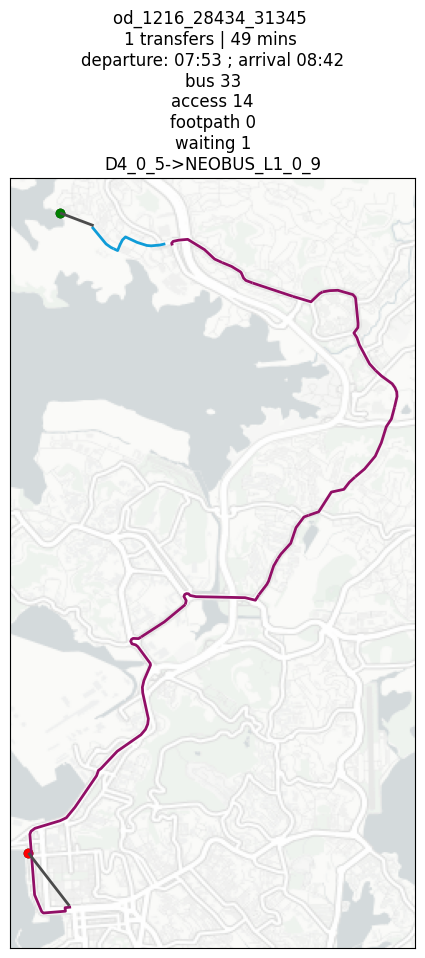

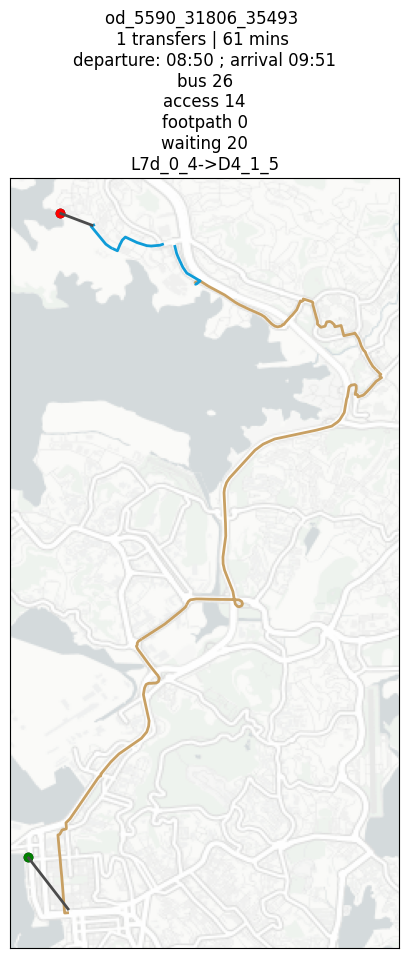

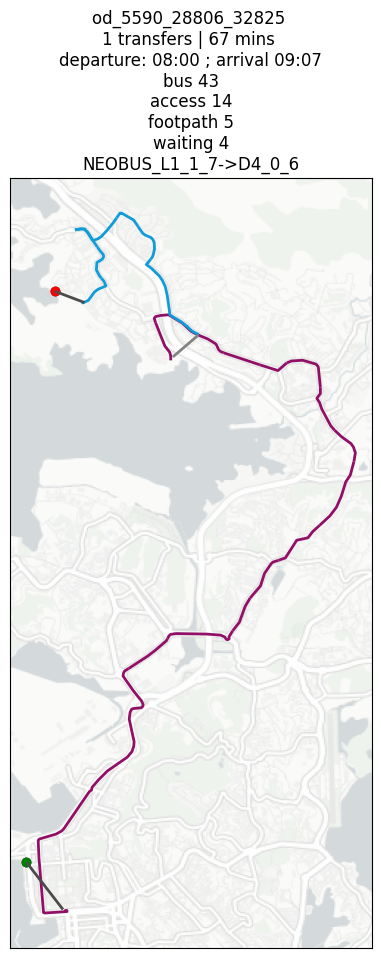

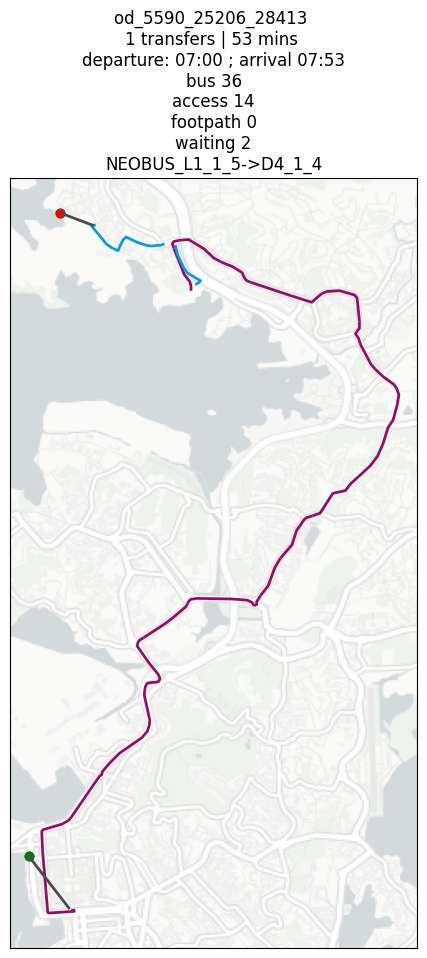

In [112]:
od_route.to_crs(epsg='4326', inplace=True)
model = model.change_epsg(epsg='4326', coordinates_unit = 'degree')

for origin, destination, itinerary_id in pt_los[['origin', 'destination', 'itinerary_id']].values:
    fig, ax = plt.subplots(figsize=(10, 10))
    route = od_route[od_route['itinerary_id'] == itinerary_id]
    model.od_basemap(origin=origin, destination=destination, squared=True, figsize=(10, 10), ax=ax)
    plot_lineStrings(route, ax=ax, linewidth=2, colors=route['route_color'])

    model.zones.loc[[origin]].plot(ax=ax, color='green')
    model.zones.loc[[destination]].plot(ax=ax, color='red')

    create_basemap(ax)

    ax.set_xticks([])
    ax.set_yticks([])

    title = f'{itinerary_id} \n'

    path = pt_los[pt_los['itinerary_id'] == itinerary_id].iloc[0]
    path['min'] = np.round(path['time'] / 60).astype(int)
    mins = (
        (path[time_cols + ['time']] / 60)
        .astype(int)
        .astype(str)
    )
    title += f'{path['ntransfers']} transfers | {path['min']} mins '
    title += '\n' + 'departure: {}'.format(seconds_time(path['departure_time'])) + ' ; arrival {}'.format(seconds_time(path['arrival_time']))
    for col in time_cols:
        title += '\n' + col.replace('_time', ' ') + mins[col]

    trip_dict = model.links['trip_id'].to_dict()
    trip_list = route['link_path'].apply(trip_dict.get).drop_duplicates().dropna().to_list()
    title += '\n'
    title += '->'.join(trip_list)
    ax.set_title(title)

    #png = f'OD_PT_{name}.png'
    #fig.savefig(os.path.join(output_folder, png), bbox_inches='tight')


In [102]:
model.od_basemap?

Signature:
model.od_basemap(
    origin,
    destination,
    alpha=0.5,
    color='grey',
    squared=False,
    *args,
    **kwargs,
)
Docstring: <no docstring>
File:      c:\users\lrapin\dev\quetzal\quetzal\model\plotmodel.py
Type:      method

In [99]:
pt_los.set_index('itinerary_id')

,origin,destination,departure_time,arrival_time,last_connection,csa_path,path,link_path,boarding_links,ntransfers,...,time,gtime,time (mins),route_types,route_type,bus_time,walk_time,access_time,footpath_time,waiting_time
itinerary_id,,,,,,,,,,,,,,,,,,,,,
od_1216_28434_31345,od_1216_o,od_1216_d,28434.066738,31345.739728,ztt_ztt_1216_2870,"[od_1216_o, ztt_ztt_1216_2870, link_267, link_...","[od_1216_o, ztt_ztt_1216_2870, link_267, link_...","[link_267, link_268, link_5960, link_5961, lin...","[link_267, link_5960]",1,...,2911.67299,2911.67299,48.527883,"(bus,)",bus,1981.0,854.672990,854.67299,0.000000,76.000000
od_5590_31806_35493,od_5590_o,od_5590_d,31806.260272,35493.933262,ztt_ztt_32486_170005,"[od_5590_o, ztt_ztt_32486_170005, link_3609, l...","[od_5590_o, ztt_ztt_32486_170005, link_3609, l...","[link_3609, link_3610, link_3611, link_3612, l...","[link_3609, link_613]",1,...,3687.67299,3687.67299,61.461217,"(bus,)",bus,1585.0,854.672990,854.67299,0.000000,1248.000000
od_5590_28806_32825,od_5590_o,od_5590_d,28806.260272,32825.933262,ztt_ztt_32486_170016,"[od_5590_o, ztt_ztt_32486_170016, link_6214, l...","[od_5590_o, ztt_ztt_32486_170016, link_6214, l...","[link_6214, link_6215, link_6216, link_6217, l...","[link_6214, link_294]",1,...,4019.67299,4019.67299,66.994550,"(bus,)",bus,2598.0,1168.570021,854.67299,313.897031,253.102969
od_5590_25206_28413,od_5590_o,od_5590_d,25206.260272,28413.933262,ztt_ztt_32486_170002,"[od_5590_o, ztt_ztt_32486_170002, link_6182, l...","[od_5590_o, ztt_ztt_32486_170002, link_6182, l...","[link_6182, link_6183, link_6184, link_6185, l...","[link_6182, link_579]",1,...,3207.67299,3207.67299,53.461217,"(bus,)",bus,2187.0,854.672990,854.67299,0.000000,166.000000


In [100]:
od_route.loc[od_route['itinerary_id'] == 'od_5590_27248_32825']

,od_index,itinerary_id,itinerary_departure_time,itinerary_arrival_time,gtime,link_path,a,b,route_color,departure_time,arrival_time,geometry,time,speed,trip_id,type,mode


In [101]:
print('success')

success
